# Step 1: Data Preparation & Modeling
### Retail Customer Shopping Behavior & Trends Analysis

This notebook cleans and transforms the raw consumer shopping dataset, then enriches it
with simulated transaction-level fields (purchase date, sales channel) and engineered
features so it's ready for the SQL analysis and Power BI stages of the project.

**Run all cells top to bottom** (Runtime → Run all).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. Load the raw dataset
Reading directly from the public GitHub repo, so there's no need to upload anything manually.

In [ ]:
RAW_URL = "https://raw.githubusercontent.com/amlanmohanty1/customer-trends-data-analysis-SQL-Python-PowerBI/main/customer_shopping_behavior.csv"

df = pd.read_csv(RAW_URL)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 3900 rows, 18 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. Clean column names
Convert headers to snake_case so they map cleanly onto SQL columns later.

In [ ]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)
df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount_usd',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'promo_code_used',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases']

## 3. Handle missing values
`review_rating` has a few missing entries. We impute using the **median rating within
each product category**, since ratings vary meaningfully by category and this is a
better estimate than a single global average.

In [ ]:
missing_before = df['review_rating'].isna().sum()

df['review_rating'] = df.groupby('category')['review_rating'].transform(
    lambda s: s.fillna(s.median())
)

print(f"Imputed {missing_before} missing review_rating values (category median)")
df.isnull().sum()

Imputed 37 missing review_rating values (category median)


,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount_usd,0
location,0
size,0
color,0
season,0


## 4. Remove duplicates

In [ ]:
rows_before = len(df)
df = df.drop_duplicates()
print(f"Removed {rows_before - len(df)} duplicate rows")

Removed 0 duplicate rows


## 5. Simulate purchase dates
The raw dataset only records a `season` label, not a real date. We assign each row a
random date drawn from its season's date window across 2023. This gives the SQL stage
a genuine transactions table to run time-based queries against (monthly trends,
seasonality, etc.).

In [ ]:
season_windows = {
    "Winter": [("2023-01-01", "2023-02-28"), ("2023-12-01", "2023-12-31")],
    "Spring": [("2023-03-01", "2023-05-31")],
    "Summer": [("2023-06-01", "2023-08-31")],
    "Fall":   [("2023-09-01", "2023-11-30")],
}

def random_date(season):
    windows = season_windows[season]
    start, end = windows[np.random.randint(len(windows))]
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    days_range = (end - start).days
    return start + pd.Timedelta(days=np.random.randint(0, days_range + 1))

df['purchase_date'] = df['season'].apply(random_date)
df[['season', 'purchase_date']].head()

,season,purchase_date
0,Winter,2023-02-21
1,Winter,2023-01-15
2,Spring,2023-05-11
3,Spring,2023-04-30
4,Spring,2023-03-21


## 6. Simulate sales channel (Online vs. Offline)
`Store Pickup` implies an in-store leg of the transaction, so those rows are marked
**Offline**. All other shipping types imply the order was placed **Online**, with a
small amount of random noise added so the split isn't a perfectly clean rule (real
retail data never is).

In [ ]:
base_channel = np.where(df['shipping_type'] == 'Store Pickup', 'Offline', 'Online')
noise_mask = np.random.rand(len(df)) < 0.08  # 8% random flips for realism
flipped = np.where(base_channel == 'Online', 'Offline', 'Online')
df['sales_channel'] = np.where(noise_mask, flipped, base_channel)

df['sales_channel'].value_counts(normalize=True).round(3)

,proportion
sales_channel,
Online,0.787
Offline,0.213


## 7. Feature engineering
- **age_group**: demographic bucket for segmentation
- **\*_flag columns**: Yes/No → 1/0, easier to aggregate in SQL/Power BI
- **customer_value_score**: spend scaled by purchase history
- **high_value_customer**: top 20% of customers by value score

In [ ]:
bins = [0, 24, 34, 44, 54, 64, 120]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

for col in ['subscription_status', 'discount_applied', 'promo_code_used']:
    df[f'{col}_flag'] = (df[col] == 'Yes').astype(int)

df['customer_value_score'] = (
    df['purchase_amount_usd'] * np.log1p(df['previous_purchases'])
).round(2)

threshold = df['customer_value_score'].quantile(0.8)
df['high_value_customer'] = (df['customer_value_score'] >= threshold).astype(int)

df[['customer_value_score', 'high_value_customer']].describe()

,customer_value_score,high_value_customer
count,3900.000000,3900.000000
mean,181.587223,0.200513
std,88.235985,0.400435
min,14.560000,0.000000
25%,108.650000,0.000000
50%,170.530000,0.000000
75%,247.850000,0.000000
max,393.180000,1.000000


## 8. Reorder columns for readability

In [ ]:
lead_cols = ['customer_id', 'purchase_date', 'sales_channel']
other_cols = [c for c in df.columns if c not in lead_cols]
df = df[lead_cols + other_cols]
df.head()

,customer_id,purchase_date,sales_channel,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,subscription_status_flag,discount_applied_flag,promo_code_used_flag,customer_value_score,high_value_customer
0,1,2023-02-21,Online,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,55-64,1,1,1,143.53,0
1,2,2023-01-15,Online,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-24,1,1,1,70.31,0
2,3,2023-05-11,Online,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,45-54,1,1,1,232.00,0
3,4,2023-04-30,Online,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-24,1,1,1,352.08,1
4,5,2023-03-21,Offline,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,45-54,1,1,1,169.82,0


## 9. Quick EDA
A few sanity-check visuals before moving to SQL.

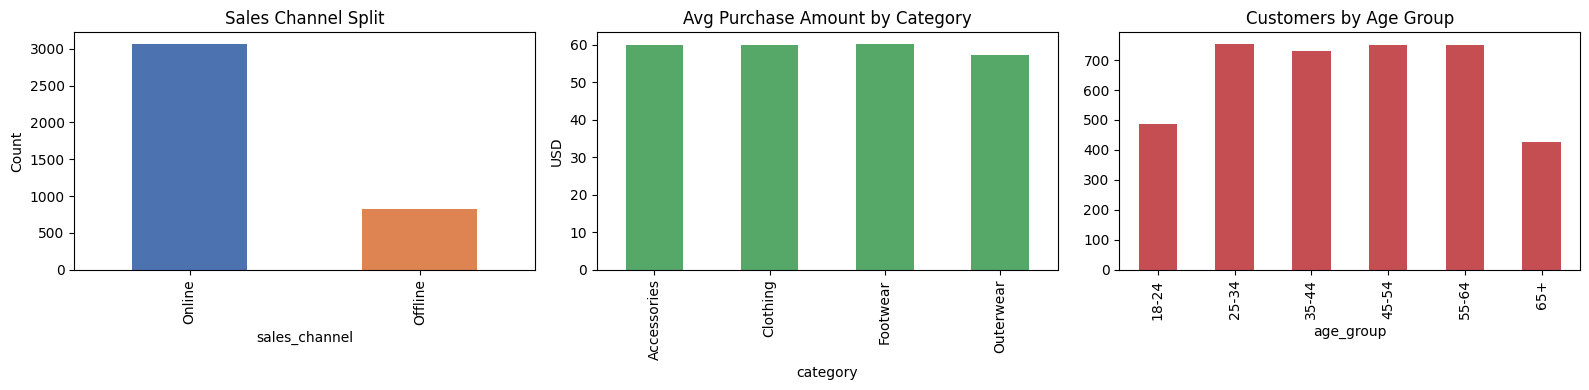

High value customers: 782 / 3900


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['sales_channel'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Sales Channel Split')
axes[0].set_ylabel('Count')

df.groupby('category')['purchase_amount_usd'].mean().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Avg Purchase Amount by Category')
axes[1].set_ylabel('USD')

df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Customers by Age Group')

plt.tight_layout()
plt.show()

print("High value customers:", df['high_value_customer'].sum(), "/", len(df))

## 10. Save & download the cleaned dataset
This is the file you'll load into SQL in Step 2.

In [ ]:
OUTPUT_PATH = "cleaned_customer_shopping_data.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved -> {OUTPUT_PATH} ({len(df)} rows, {len(df.columns)} columns)")

# Uncomment to download directly from Colab to your machine:
# from google.colab import files
# files.download(OUTPUT_PATH)

Saved -> cleaned_customer_shopping_data.csv (3900 rows, 26 columns)
